In [ ]:
# Dataset
# https://www.kaggle.com/datasets/blastchar/telco-customer-churn

In [450]:
import pandas as pd

In [451]:
df=pd.read_csv('WA_Fn-UseC_-Telco-Customer-Churn.csv')

In [ ]:
df.shape 

(7043, 21)

In [453]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 7043 entries, 0 to 7042
Data columns (total 21 columns):
 #   Column            Non-Null Count  Dtype  
---  ------            --------------  -----  
 0   customerID        7043 non-null   object 
 1   gender            7043 non-null   object 
 2   SeniorCitizen     7043 non-null   int64  
 3   Partner           7043 non-null   object 
 4   Dependents        7043 non-null   object 
 5   tenure            7043 non-null   int64  
 6   PhoneService      7043 non-null   object 
 7   MultipleLines     7043 non-null   object 
 8   InternetService   7043 non-null   object 
 9   OnlineSecurity    7043 non-null   object 
 10  OnlineBackup      7043 non-null   object 
 11  DeviceProtection  7043 non-null   object 
 12  TechSupport       7043 non-null   object 
 13  StreamingTV       7043 non-null   object 
 14  StreamingMovies   7043 non-null   object 
 15  Contract          7043 non-null   object 
 16  PaperlessBilling  7043 non-null   object 


In [454]:
df.head()

,customerID,gender,SeniorCitizen,Partner,Dependents,tenure,PhoneService,MultipleLines,InternetService,OnlineSecurity,...,DeviceProtection,TechSupport,StreamingTV,StreamingMovies,Contract,PaperlessBilling,PaymentMethod,MonthlyCharges,TotalCharges,Churn
0,7590-VHVEG,Female,0,Yes,No,1,No,No phone service,DSL,No,...,No,No,No,No,Month-to-month,Yes,Electronic check,29.85,29.85,No
1,5575-GNVDE,Male,0,No,No,34,Yes,No,DSL,Yes,...,Yes,No,No,No,One year,No,Mailed check,56.95,1889.5,No
2,3668-QPYBK,Male,0,No,No,2,Yes,No,DSL,Yes,...,No,No,No,No,Month-to-month,Yes,Mailed check,53.85,108.15,Yes
3,7795-CFOCW,Male,0,No,No,45,No,No phone service,DSL,Yes,...,Yes,Yes,No,No,One year,No,Bank transfer (automatic),42.30,1840.75,No
4,9237-HQITU,Female,0,No,No,2,Yes,No,Fiber optic,No,...,No,No,No,No,Month-to-month,Yes,Electronic check,70.70,151.65,Yes


In [455]:
df.duplicated().sum()

0

In [456]:
df.isnull().sum()

customerID          0
gender              0
SeniorCitizen       0
Partner             0
Dependents          0
tenure              0
PhoneService        0
MultipleLines       0
InternetService     0
OnlineSecurity      0
OnlineBackup        0
DeviceProtection    0
TechSupport         0
StreamingTV         0
StreamingMovies     0
Contract            0
PaperlessBilling    0
PaymentMethod       0
MonthlyCharges      0
TotalCharges        0
Churn               0
dtype: int64

In [457]:
df['Churn'].value_counts()

Churn
No     5174
Yes    1869
Name: count, dtype: int64

In [458]:
df=df.drop('customerID',axis=1)

In [459]:
df.corr(numeric_only=True)

,SeniorCitizen,tenure,MonthlyCharges
SeniorCitizen,1.000000,0.016567,0.220173
tenure,0.016567,1.000000,0.247900
MonthlyCharges,0.220173,0.247900,1.000000


In [460]:
df['TotalCharges']=pd.to_numeric(df['TotalCharges'],errors='coerce')

In [461]:
df['TotalCharges']=df['TotalCharges'].fillna(df['TotalCharges']).median()

In [ ]:
X=df.drop(columns='Churn',axis=1)
y=df['Churn'].map({'No':0,"Yes":1})

In [463]:
num_cols=X.select_dtypes(include='number').columns
cat_cols=X.select_dtypes(include='object').columns

In [464]:
for col in cat_cols:
    print('\n',col)
    print(df[col].unique())


 gender
['Female' 'Male']

 Partner
['Yes' 'No']

 Dependents
['No' 'Yes']

 PhoneService
['No' 'Yes']

 MultipleLines
['No phone service' 'No' 'Yes']

 InternetService
['DSL' 'Fiber optic' 'No']

 OnlineSecurity
['No' 'Yes' 'No internet service']

 OnlineBackup
['Yes' 'No' 'No internet service']

 DeviceProtection
['No' 'Yes' 'No internet service']

 TechSupport
['No' 'Yes' 'No internet service']

 StreamingTV
['No' 'Yes' 'No internet service']

 StreamingMovies
['No' 'Yes' 'No internet service']

 Contract
['Month-to-month' 'One year' 'Two year']

 PaperlessBilling
['Yes' 'No']

 PaymentMethod
['Electronic check' 'Mailed check' 'Bank transfer (automatic)'
 'Credit card (automatic)']


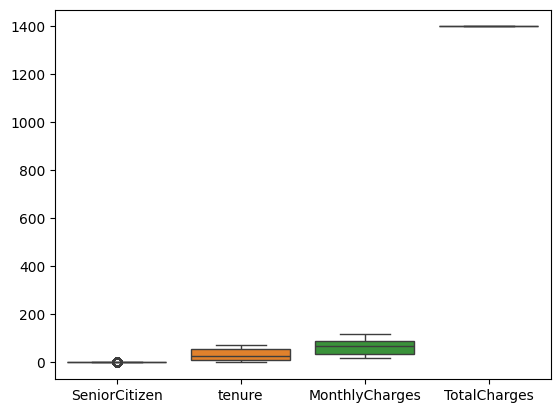

In [465]:
import seaborn as sns
import matplotlib.pyplot as plt
sns.boxplot(df[num_cols])
plt.show()

In [466]:
from sklearn.model_selection import train_test_split

Xtrain,Xtest,ytrain,ytest=train_test_split(X,y,train_size=0.8,random_state=42)

In [ ]:
from sklearn.preprocessing import MinMaxScaler,RobustScaler,OneHotEncoder
from imblearn.pipeline import Pipeline
from sklearn.compose import ColumnTransformer
from sklearn.linear_model import LogisticRegression
from imblearn.over_sampling import SMOTE

In [468]:
preprocessor=ColumnTransformer(
    transformers=[
        ('scale',MinMaxScaler(),['TotalCharges','tenure','MonthlyCharges']),
        ('sclaer',RobustScaler(),['SeniorCitizen']),
        ('encoder',OneHotEncoder(handle_unknown='ignore'),cat_cols)
    ]
)

In [469]:
main_pipe=Pipeline(
    steps=[
        ('pre',preprocessor),
        ('over',SMOTE(random_state=42)),
        ('model',LogisticRegression(class_weight='balanced',max_iter=1000))
    ]
)

In [470]:
main_pipe.fit(Xtrain,ytrain)

,steps,"[('pre', ...), ('over', ...), ...]"
,transform_input,None
,memory,None
,verbose,False
,transformers,"[('scale', ...), ('sclaer', ...), ...]"
,remainder,'drop'
,sparse_threshold,0.3
,n_jobs,None
,transformer_weights,None
,verbose,False
,verbose_feature_names_out,True


In [471]:
ypred_train=main_pipe.predict(Xtrain)
ypred_test=main_pipe.predict(Xtest)

In [472]:
from sklearn.metrics import classification_report,confusion_matrix,accuracy_score

In [473]:
print('Train:')
print('Classification Report: \n',classification_report(ytrain,ypred_train))
print('accuracy_score: ',accuracy_score(ytrain,ypred_train))
print('confusion_matrix: \n',confusion_matrix(ytrain,ypred_train))

Train:
Classification Report: 
               precision    recall  f1-score   support

           0       0.91      0.75      0.82      4138
           1       0.53      0.78      0.63      1496

    accuracy                           0.76      5634
   macro avg       0.72      0.76      0.72      5634
weighted avg       0.80      0.76      0.77      5634

accuracy_score:  0.755591054313099
confusion_matrix: 
 [[3083 1055]
 [ 322 1174]]


In [474]:
print('Test:')
print('Classification Report: \n',classification_report(ytest,ypred_test))
print('accuracy_score: ',accuracy_score(ytest,ypred_test))
print('confusion_matrix: \n',confusion_matrix(ytest,ypred_test))

Test:
Classification Report: 
               precision    recall  f1-score   support

           0       0.92      0.75      0.82      1036
           1       0.54      0.82      0.65       373

    accuracy                           0.77      1409
   macro avg       0.73      0.78      0.74      1409
weighted avg       0.82      0.77      0.78      1409

accuracy_score:  0.7650816181689141
confusion_matrix: 
 [[774 262]
 [ 69 304]]


In [475]:
ytrain.value_counts()

Churn
0    4138
1    1496
Name: count, dtype: int64

In [476]:
from xgboost import XGBClassifier


In [477]:
main_pipe_XG=Pipeline(
    steps=[
        ('pre',preprocessor),
        ('over',SMOTE(random_state=42)),
        ('model',XGBClassifier(
    n_estimators=300,
    max_depth=4,
    learning_rate=0.05,
    subsample=0.8,
    colsample_bytree=0.8,
    random_state=42,
    eval_metric='logloss'
))
    ]
)

In [478]:
xg=main_pipe_XG.fit(Xtrain,ytrain)

In [479]:
ypred_train_XG=xg.predict(Xtrain)
ypred_test_XG=xg.predict(Xtest)

In [480]:
print('Train:')
print('Classification Report: \n',classification_report(ytrain,ypred_train_XG))
print('accuracy_score: ',accuracy_score(ytrain,ypred_train_XG))
print('confusion_matrix: \n',confusion_matrix(ytrain,ypred_train_XG))


Train:
Classification Report: 
               precision    recall  f1-score   support

           0       0.88      0.87      0.88      4138
           1       0.65      0.68      0.66      1496

    accuracy                           0.82      5634
   macro avg       0.77      0.77      0.77      5634
weighted avg       0.82      0.82      0.82      5634

accuracy_score:  0.8178913738019169
confusion_matrix: 
 [[3592  546]
 [ 480 1016]]


In [481]:
print('Test:')
print('Classification Report: \n',classification_report(ytest,ypred_test_XG))
print('accuracy_score: ',accuracy_score(ytest,ypred_test_XG))
print('confusion_matrix: \n',confusion_matrix(ytest,ypred_test_XG))

Test:
Classification Report: 
               precision    recall  f1-score   support

           0       0.88      0.85      0.86      1036
           1       0.62      0.66      0.64       373

    accuracy                           0.80      1409
   macro avg       0.75      0.76      0.75      1409
weighted avg       0.81      0.80      0.80      1409

accuracy_score:  0.801277501774308
confusion_matrix: 
 [[881 155]
 [125 248]]
